# 3.0. **Modeling - LogisticRegression**:

> 3.1. **Baseline Model: Dummy Classifier** <br>
> 3.2. **Bayesian Optimization (BayesSearchCV)** <br>
> 3.3. **Training the Model - Fit Logistic Regression** <br>
> 3.4. **Predict & Evaluate** <br>
> 3.5. **Classification Report & Confusion Matrix** <br>
> 3.6. **Credit Scorecard** <br>
> 3.7. **PCA 2D Visualization** <br>
> 3.8. **LogReg + BorderlineSMOTE**

<br>

In [1]:
# Libraries
import pandas as pd
import numpy as np

# Logging
import logging
import time

# CPU Cores & System
import os
import sys

# Jalankan ini hanya jika posisi aktif masih di dalam folder notebooks
if os.getcwd().endswith('notebooks'):
    %cd ..

# Viz libraries
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

# Plotting options
%matplotlib inline
mpl.style.use('ggplot')
sns.set(style='whitegrid')

# Import warnings
import warnings
warnings.filterwarnings('ignore')

# Pandas set_option
pd.set_option('display.max_columns', None)

/home/gontommuhammad/credit_risk_modeling


In [2]:
from src.utils import deserialize_data

# X set:
X_train_lr = deserialize_data('data/processed/logreg/X_train_lr.pkl')
X_valid_lr = deserialize_data('data/processed/logreg/X_valid_lr.pkl')
X_test_lr  = deserialize_data('data/processed/logreg/X_test_lr.pkl')

# y set:
y_train = deserialize_data('data/interim/y_train.pkl')
y_valid = deserialize_data('data/interim/y_valid.pkl')
y_test  = deserialize_data('data/interim/y_test.pkl')

Data successfully deserialized from data/processed/logreg/X_train_lr.pkl
Data successfully deserialized from data/processed/logreg/X_valid_lr.pkl
Data successfully deserialized from data/processed/logreg/X_test_lr.pkl
Data successfully deserialized from data/interim/y_train.pkl
Data successfully deserialized from data/interim/y_valid.pkl
Data successfully deserialized from data/interim/y_test.pkl


In [3]:
RANDOM_STATE = 42

<br>

---
### Split Data: from Train Set for Calibration Set:

In [4]:
print(f"X_train shape: {X_train_lr.shape}, y_train shape: {y_train.shape}")

X_train shape: (84764, 75), y_train shape: (84764,)


In [5]:
TRAIN_CAL_SIZE = 10 / 90

from src.utils import split_train_test
X_train_lr, X_train_cal, y_train, y_train_cal = split_train_test(
    X_train_lr, 
    y_train,
    test_size=TRAIN_CAL_SIZE, 
    stratify=y_train,
    seed=RANDOM_STATE
)

In [6]:
print(f"X_train shape: {X_train_lr.shape}, y_train shape: {y_train.shape}")

X_train shape: (75345, 75), y_train shape: (75345,)


In [7]:
print(f"X_train cal shape: {X_train_cal.shape}, y_train cal shape: {y_train_cal.shape}")

X_train cal shape: (9419, 75), y_train cal shape: (9419,)


<br>

---
### Import Metrics from Scikit Learn:

In [8]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, log_loss, 
    matthews_corrcoef, classification_report, confusion_matrix, balanced_accuracy_score, 
    average_precision_score, brier_score_loss, precision_recall_curve, accuracy_score
)

<br>

---
## **1.1. Baseline Model: Dummy Classifier**:

In [9]:
from sklearn.dummy import DummyClassifier
# Create an object
dummy_clf = DummyClassifier(
    strategy='most_frequent',
    random_state=RANDOM_STATE
)
# Perform a fit, for y_train data only
dummy_clf.fit(
    X=X_train_lr, 
    y=y_train
)

DummyClassifier(random_state=42, strategy='most_frequent')

In [10]:
# Predict
y_pred_dummy = dummy_clf.predict(X_train_lr)

In [11]:
# Confusion matrix
confusion_matrix(
    y_true=y_train,
    y_pred=y_pred_dummy
)
# [[tn, fp]]
# [[fn, tp]]

array([[63862,     0],
       [11483,     0]])

In [12]:
# Accuracy score
accuracy_score(
    y_true=y_train,
    y_pred=y_pred_dummy
)
# Same as the largest class proportion

0.8475943990974849

**BASELINE PRIOR CLASS PROBABILITY**
- Find the probability of each class appearing
- Find the proportion of each class appearing in the training data
- Find the total odds of the class appearing based on the prior probability

In [13]:
print(f"y_train  :", y_train.value_counts(normalize=True))
print(f'y_valid  :', y_valid.value_counts(normalize=True))
print(f'y_test   :', y_test.value_counts(normalize=True))

y_train  : target
0    0.847594
1    0.152406
Name: proportion, dtype: float64
y_valid  : target
0    0.847584
1    0.152416
Name: proportion, dtype: float64
y_test   : target
0    0.860549
1    0.139451
Name: proportion, dtype: float64


In [14]:
# Odds of guessing minority correct:
proba_minority = 0.225043
proportion_minority = y_train.value_counts(normalize=True)[1]

odds_minority = proba_minority * proportion_minority
odds_minority

np.float64(0.034297813643904704)

In [15]:
# Odds of guessing majority correct:
proba_majority = 0.774957
proportion_majority = y_train.value_counts(normalize=True)[0]

odds_majority = proba_majority * proportion_majority
odds_majority

np.float64(0.6568492127413896)

In [16]:
# Odds total
odds_minority + odds_majority

np.float64(0.6911470263852943)

In [17]:
# Create an object
dummy_clf = DummyClassifier(
    strategy='stratified',
    random_state=RANDOM_STATE
)
# Perform a fit, for y_train data only
dummy_clf.fit(
    X=X_train_lr,
    y=y_train
)

DummyClassifier(random_state=42, strategy='stratified')

In [18]:
# Predict
y_pred_dummy = dummy_clf.predict(X_train_lr)

In [19]:
# Display confusion matrix
confusion_matrix(
    y_true=y_train,
    y_pred=y_pred_dummy
)
# [[tn, fp]]
# [[fn, tp]]

array([[54142,  9720],
       [ 9794,  1689]])

In [20]:
# Check accuracy
accuracy_score(
    y_true=y_train,
    y_pred=y_pred_dummy
)

0.7410047116596987

In [21]:
# Balanced accuracy
balanced_accuracy_score(
    y_true=y_train,
    y_pred=y_pred_dummy
)

np.float64(0.4974419050234082)

In [22]:
# Calculate performance metrics
precision = precision_score(
    y_train, 
    y_pred_dummy, 
    pos_label=1, 
    zero_division=0
)
recall = recall_score(
    y_train, 
    y_pred_dummy, 
    pos_label=1
)
f1 = f1_score(
    y_train, 
    y_pred_dummy, 
    average='weighted'
)
roc_auc = roc_auc_score(
    y_train, 
    dummy_clf.predict_proba(X_train_lr)[:, 1]
)
# Print the results
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

Precision : 0.1480
Recall    : 0.1471
F1 Score  : 0.7407
ROC AUC   : 0.4974


In [23]:
# Buat weight class
n_samples = len(y_train)
n_classes = len(y_train.value_counts())
n_samples_j = y_train.value_counts()

class_weight = n_samples / (n_classes * n_samples_j)
class_weight

# We give more weight to class 1

target
0    0.589905
1    3.280719
Name: count, dtype: float64

<br>

---
## **1.2. Bayesian Optimization (BayesSearchCV)**:

In [24]:
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from skopt.space import Real, Integer, Categorical
from tqdm.auto import tqdm
from joblib import parallel_backend

In [26]:
# # ── Search Space ───────────────────────────────────────────────────────────
# # Effective dimension: 2D continuous.
# # ElasticNet includes L1 (l1_ratio=1.0) and L2 (l1_ratio=0.0) as boundary cases 
# # — no expressivity loss compared to separate penalty search, without the risk of conditional constraint violation.
# search_spaces = {
#     'C':         Real(1e-4, 1e3, prior='log-uniform'),
#     'l1_ratio':  Real(0.0, 1.0),   # l1_ratio=1 ≡ L1; l1_ratio=0 ≡ L2
# }

# # ── Locked Estimator ───────────────────────────────────────────────────────
# lr_estimator = LogisticRegression(
#     # penalty and solver MUST be locked together:
#     # 'elasticnet' is only valid with 'saga'; other solvers are not supported.
#     # Include solver as a search parameter with penalty='elasticnet'
#     # will always result in a ValueError for solvers other than saga.
#     penalty='elasticnet',
#     solver='saga',
#     # SAGA requires more iterations than lbfgs for convergence on large datasets; 
#     # 2000 is safe for ~155K training samples.
#     max_iter=2000,  
#     # `class_weight` is locked to None: consistent with XGBoost (scale_pos_weight) and 
#     # CatBoost (auto_class_weights) decisions; imbalance is handled via threshold optimization.
#     class_weight=None,
#     # Parallelism is delegated to BayesSearchCV (n_jobs=-1)
#     n_jobs=-1, 
#     random_state=42,
# )

# # ── BayesSearchCV ──────────────────────────────────────────────────────────
# bayes_search = BayesSearchCV(
#     estimator=lr_estimator,
#     search_spaces=search_spaces,
#     n_iter=40,           # Capable of continuous 2D; 60 gives diminishing returns
#     cv=StratifiedKFold(
#         n_splits=6,
#         shuffle=True,
#         random_state=RANDOM_STATE,
#     ),
#     scoring='neg_log_loss',
#     n_jobs=1,
#     random_state=RANDOM_STATE,
#     refit=True,
#     return_train_score=True,
#     verbose=0,
# )

# # Run BayesSearchCV
# # Setup Logging to file
# for handler in logging.root.handlers[:]:
#     logging.root.removeHandler(handler)
    
# logging.basicConfig(
#     level=logging.INFO, 
#     filename='bayes_search.log', 
#     filemode='w', 
#     format='%(asctime)s - %(message)s'
# )

# # Custom Callback for Progress and Logging
# class TqdmProgressCallback:
#     def __init__(self, total_iter):
#         self.total_iter = total_iter
#         self.pbar = tqdm(
#             total=total_iter, 
#             desc='BayesSearch Iterations', 
#             unit='iter'
#         )
#         self.logger = logging.getLogger()

#     def __call__(self, result):
#         # Log each iteration's results
#         current_iter = len(result.x_iters)
        
#         # Menggunakan logging.getLogger() secara langsung di dalam scope 
#         # lebih aman untuk menghindari pickling pada variabel global 'logger'
#         self.logger.info(f"Iteration {current_iter}/{self.total_iter}: Parameters {result.x}, Score {result.fun}")
        
#         # Update progress bar
#         if self.pbar is not None:
#             self.pbar.update(1)

#     def close(self):
#         if self.pbar is not None:
#             self.pbar.close()

#     # Prevent PicklingError
#     def __getstate__(self):
#         # Saat akan di-pickle ke worker, kita hapus 'pbar' dari state yang dikirim
#         state = self.__dict__.copy()
#         if 'pbar' in state:
#             del state['pbar']
#         return state

#     def __setstate__(self, state):
#         # Saat diterima oleh worker (di-unpickle), set pbar menjadi None
#         self.__dict__.update(state)
#         self.pbar = None

# # Initialize progress callback
# progress_callback = TqdmProgressCallback(
#     total_iter=bayes_search.n_iter
# )
# # Attach callback to BayesSearchCV
# logging.getLogger().info(f"Starting BayesSearchCV...")
# bayes_search.fit(
#     X_train_lr, 
#     y_train,
#     callback=progress_callback
# )

# # Close progress bar
# progress_callback.close()

# # Showing the best parameters
# best_params = bayes_search.best_params_
# print(f"Best parameters:", best_params)

<br>

---
## **1.3. Training the Model - Fit Logistic Regression:**

In [27]:
# Import library
from sklearn.linear_model import LogisticRegression

In [28]:
# logreg = LogisticRegression(
#     C=0.2966113513503939,
#     class_weight=None,
#     l1_ratio=1.0,
#     max_iter=2000,
#     penalty='elasticnet',
#     random_state=RANDOM_STATE,
#     solver='saga'
# )
# logreg.fit(X_train_lr, y_train)

logreg = LogisticRegression(
    C=0.38461013019343815,
    class_weight=None,
    l1_ratio=0.4754992118174114,
    max_iter=2000,
    penalty='elasticnet',
    random_state=RANDOM_STATE,
    solver='saga'
)
logreg.fit(X_train_lr, y_train)

LogisticRegression(C=0.38461013019343815, l1_ratio=0.4754992118174114,
                   max_iter=2000, penalty='elasticnet', random_state=42,
                   solver='saga')


---
## **1.4. Predict & Evaluate**

<br>

### **F1 Threshold**: 

F1 Threshold: 0.1587


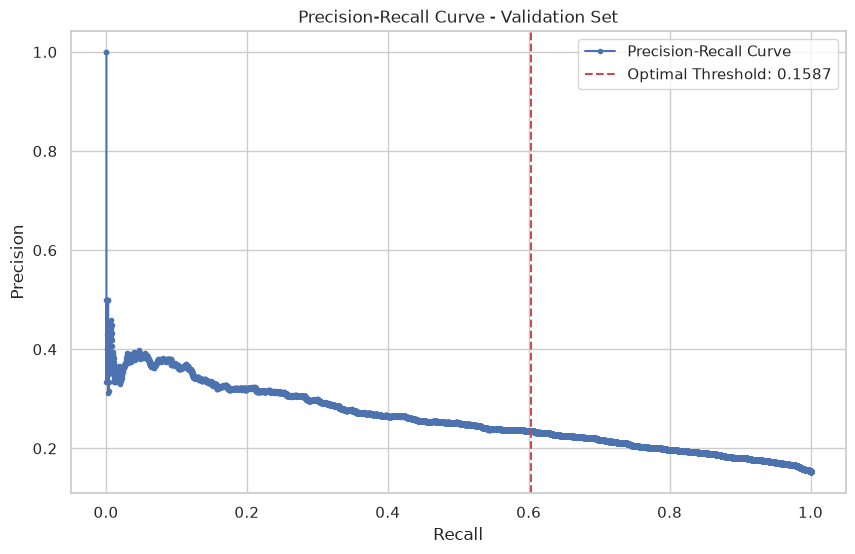

In [29]:
# PR curve only in Validation Set
precisions, recalls, thresholds = precision_recall_curve(
    y_valid,
    logreg.predict_proba(X_valid_lr)[:, 1]
)

# Align arrays
precisions_t = precisions[:-1]
recalls_t = recalls[:-1]

# F1 per threshold
f1_scores = np.where(
    (precisions_t + recalls_t) > 0,
    2 * precisions_t * recalls_t / (precisions_t + recalls_t),
    0
)
optimal_idx = np.argmax(f1_scores)
f1_threshold = thresholds[optimal_idx]

print(f"F1 Threshold: {f1_threshold:.4f}")

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, marker='.', label=f"Precision-Recall Curve")
plt.axvline(recalls[optimal_idx], color='r', linestyle='--', label=f"Optimal Threshold: {f1_threshold:.4f}")
plt.xlabel(f"Recall")
plt.ylabel(f"Precision")
plt.title(f"Precision-Recall Curve - Validation Set")
plt.legend()
plt.show()

<br>

### **Cost-based Threshold**:

In [30]:
# Economic parameters:
c_fn = 8_250_000.0   # Cost False Negative: EAD * LGD = 15m * 0.55
c_fp = 2_700_000.0   # Cost False Positive: EAD * spread * duration = 15m * 0.09 * 2

"""
The threshold that minimizes: 
    
E[C(tau)] = c_fn * P(y=1) * FNR(tau) + c_fp * P(y=0) * FPR(tau).

The only criterion that is genuinely independent of F1 and Youden's 
because it is based on the economic objective function, 
not statistical discrimination or precision-recall.
"""

from src.helpers import find_best_cost_threshold

# ── RUN ──
optimal_cost_threshold, optimal_cost = find_best_cost_threshold(
    y_true=y_valid, 
    y_proba=logreg.predict_proba(X_valid_lr)[:, 1],
    c_fn=c_fn, c_fp=c_fp
)
print(f"Optimal Cost-based Threshold: {optimal_cost_threshold:.4f}; Optimal Cost: {optimal_cost:.4f}")

Optimal Cost-based Threshold: 0.2432; Optimal Cost: 1166619.4790


<br>

**Function to Evaluate Modelt**:

In [31]:
def evaluate_model(
    model, 
    X, y, 
    model_name, 
    split_set, 
    threshold=None):
    """
    Evaluate binary classification model.
    
    Parameters
    ----------
    model : fitted estimator
        Trained model with predict() and predict_proba().
    
    X : array-like
        Features.
    
    y : array-like
        True labels.
    
    threshold : float
        Must be taken from Validation Set.
     
    model_name : object
    
    split_set : str
        Train / Validation / Test.
    
    Returns
    -------
    Metrics table          : pd.DataFrame
    Confusion Matrix       : pd.DataFrame
    Classification Report  : String
    y prediction           : array-like
    y probability          : array-like
    """
    
    if threshold is None:
        y_pred = model.predict(X)
    else:
        y_pred = (
            model.predict_proba(X)[:, 1] >= threshold
        ).astype(int)
    
    y_proba = model.predict_proba(X)[:, 1]
    
    from src.ks_statistic_evaluation import compute_ks_statistic
    ks_result = compute_ks_statistic(y, y_proba)
    
    from src.helpers import threshold_classification_metrics
    thres_metrics = threshold_classification_metrics(y, y_proba, threshold)
    
    metrics_df = pd.DataFrame([{
        'Model': model_name,
        'Split': split_set,
        'ROC-AUC': round(roc_auc_score(y, y_proba), 6),
        'PR-AUC': round(average_precision_score(y, y_proba), 6),
        'LogLoss': round(log_loss(y, y_proba), 6),
        'Brier Score': round(brier_score_loss(y, y_proba), 6),
        'Gini': round(2 * roc_auc_score(y, y_proba) - 1, 6),
        'KS_Statistic': round(ks_result['ks_statistic_roc'], 6),
        **thres_metrics
    }])
    
    return metrics_df, y_pred, y_proba

In [32]:
train_metrics, y_pred_train, y_proba_train = evaluate_model(
    model=logreg, 
    X=X_train_lr, y=y_train, 
    model_name='Logistic Regression', 
    split_set='Training',
    threshold=optimal_cost_threshold
)

valid_metrics, y_pred_valid, y_proba_valid = evaluate_model(
    model=logreg, 
    X=X_valid_lr, y=y_valid, 
    model_name='Logistic Regression', 
    split_set='Validation',
    threshold=optimal_cost_threshold
)

test_metrics, y_pred_test, y_proba_test = evaluate_model(
    model=logreg, 
    X=X_test_lr, y=y_test, 
    model_name='Logistic Regression', 
    split_set='Test',
    threshold=optimal_cost_threshold
)

results = pd.concat([
    train_metrics,
    valid_metrics, 
    test_metrics

], ignore_index=True).set_index(['Model', 'Split'])

results

ROC-AUC    PR-AUC   LogLoss  Brier Score  \
Model               Split                                                   
Logistic Regression Training    0.675443  0.266279  0.401551     0.122500   
                    Validation  0.671120  0.260084  0.402824     0.122969   
                    Test        0.644395  0.215537  0.390392     0.117115   

                                    Gini  KS_Statistic  Balanced_Accuracy  \
Model               Split                                                   
Logistic Regression Training    0.350886      0.253373           0.580730   
                    Validation  0.342239      0.253328           0.583586   
                    Test        0.288791      0.219454           0.563684   

                                     MCC  Precision_Bad  Recall_Bad    F1_Bad  \
Model               Split                                                       
Logistic Regression Training    0.169528       0.306276    0.272403  0.288348   
                    Validation  0.172506       0.305277    0.282972  0.293702   
                    Test        0.126978       0.248258    0.250080  0.249166   

                                Specificity       NPV       FPR       FNR  \
Model               Split                                                   
Logistic Regression Training       0.889058  0.871722  0.110942  0.727597   
                    Validation     0.884200  0.872733  0.115800  0.717028   
                    Test           0.877287  0.878332  0.122713  0.749920   

                                Predicted_Bad_Rate     TN    FP    FN    TP  
Model               Split                                                    
Logistic Regression Training              0.135550  56777  7085  8355  3128  
                    Validation            0.141280   7941  1040  1158   457  
                    Test                  0.140474  16972  2374  2351   784

<br>

---
## **1.5. Classification Report & Confusion Matrix**: <br> 

**LogReg - Training Set**:

In [33]:
from src.helpers import print_report_and_cm
print_report_and_cm(
    y_train, y_pred_train,
    f"Classification Report & Confusion Matrix | {f'Training Set'}"
)


Classification Report & Confusion Matrix | Training Set
              precision    recall  f1-score   support

    GOOD (0)       0.87      0.89      0.88     63862
     BAD (1)       0.31      0.27      0.29     11483

    accuracy                           0.80     75345
   macro avg       0.59      0.58      0.58     75345
weighted avg       0.79      0.80      0.79     75345



,Pred GOOD (0),Pred BAD (1)
Actual GOOD (0),56777,7085
Actual BAD (1),8355,3128


<br>

**LogReg - Validation Set**:

In [34]:
print_report_and_cm(
    y_valid, y_pred_valid,
    f"Classification Report & Confusion Matrix | {f'Valdation Set'}"
)


Classification Report & Confusion Matrix | Valdation Set
              precision    recall  f1-score   support

    GOOD (0)       0.87      0.88      0.88      8981
     BAD (1)       0.31      0.28      0.29      1615

    accuracy                           0.79     10596
   macro avg       0.59      0.58      0.59     10596
weighted avg       0.79      0.79      0.79     10596



,Pred GOOD (0),Pred BAD (1)
Actual GOOD (0),7941,1040
Actual BAD (1),1158,457


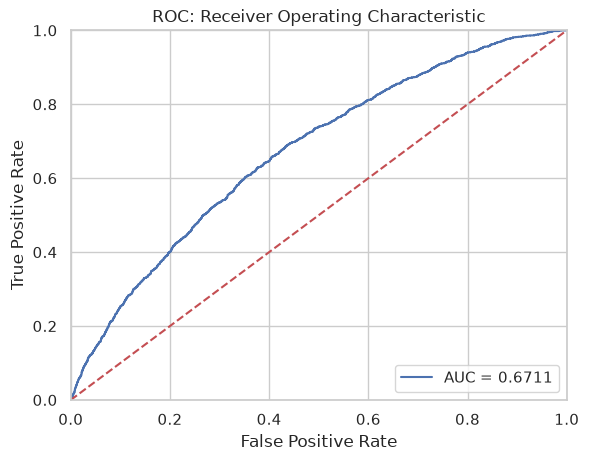

In [35]:
# ROC Curve
fpr_lr, tpr_lr, threshold_lr = roc_curve(
    y_valid,
    y_proba_valid
)
roc_auc_lr = auc(
    fpr_lr, 
    tpr_lr
)
plt.title(f"ROC: Receiver Operating Characteristic")
plt.plot(fpr_lr, tpr_lr, 'b', label = 'AUC = %0.4f' % roc_auc_lr)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel(f"True Positive Rate")
plt.xlabel(f"False Positive Rate")
plt.show()

<br>

**LogReg - Test Set**:

In [36]:
print_report_and_cm(
    y_test, y_pred_test,
    f"Classification Report & Confusion Matrix | {f'Test Set'}"
)


Classification Report & Confusion Matrix | Test Set
              precision    recall  f1-score   support

    GOOD (0)       0.88      0.88      0.88     19346
     BAD (1)       0.25      0.25      0.25      3135

    accuracy                           0.79     22481
   macro avg       0.56      0.56      0.56     22481
weighted avg       0.79      0.79      0.79     22481



,Pred GOOD (0),Pred BAD (1)
Actual GOOD (0),16972,2374
Actual BAD (1),2351,784


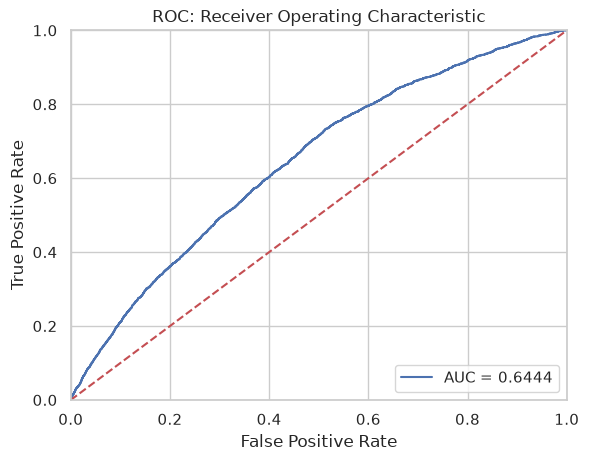

In [37]:
# ROC Curve
fpr_lr, tpr_lr, threshold_lr = roc_curve(
    y_test, 
    y_proba_test
)
roc_auc_lr = auc(
    fpr_lr, 
    tpr_lr
)
plt.title(f"ROC: Receiver Operating Characteristic")
plt.plot(fpr_lr, tpr_lr, 'b', label = 'AUC = %0.4f' % roc_auc_lr)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel(f"True Positive Rate")
plt.xlabel(f"False Positive Rate")
plt.show()

In [38]:
from src.helpers import (
    CALIBRATION_STRATEGIES, 
    extract_positive_proba, 
    run_probability_pipeline,
)

from src.calibration_selection import (
    evaluate_calibration_strategies,
    reliability_table,
    brier_skill_score
)

data_splits_logreg = {
    "train_cal": X_train_cal,   
    "valid":     X_valid_lr,   
    "test":      X_test_lr,
}

proba_store_lr = run_probability_pipeline(
    fitted_models={"logreg_scorecard": logreg},
    data_splits=data_splits_logreg,
    y_train_cal=y_train_cal,   
)

result = evaluate_calibration_strategies(
    proba_store_lr,
    y_by_split={"train_cal": y_train_cal, "valid": y_valid, "test": y_test},
    base_model_names=["logreg_scorecard"],
    decision_split="test",
)

print(result.winners)   # strategi mana yang menang + Brier/LogLoss-nya di OOT
print(result.table)     # breakdown lengkap semua strategi x semua split, untuk laporan
print(reliability_table(y_test, proba_store_lr["logreg_scorecard_cal_sigmoid"]["test"]))  # kurva kalibrasi

              model winning_strategy  brier_test  logloss_test
0  logreg_scorecard         isotonic    0.116901      0.390557
              model  strategy      split     brier   logloss
0  logreg_scorecard       raw  train_cal  0.124043  0.407064
1  logreg_scorecard       raw      valid  0.122969  0.402824
2  logreg_scorecard       raw       test  0.117115  0.390392
3  logreg_scorecard   sigmoid  train_cal  0.124381  0.408743
4  logreg_scorecard   sigmoid      valid  0.123477  0.405427
5  logreg_scorecard   sigmoid       test  0.117304  0.391670
6  logreg_scorecard  isotonic  train_cal  0.123336  0.404353
7  logreg_scorecard  isotonic      valid  0.122966  0.402721
8  logreg_scorecard  isotonic       test  0.116901  0.390557
             decile  count  mean_predicted  observed_rate
0  (0.0696, 0.0941]   2249        0.087291       0.052912
1   (0.0941, 0.103]   2248        0.098847       0.076512
2    (0.103, 0.112]   2248        0.107588       0.077402
3    (0.112, 0.122]   2248      

In [39]:
pd.DataFrame([{**brier_skill_score(y_train_cal, logreg.predict_proba(X_train_cal)[:, 1])}])

,base_rate,brier_model,brier_trivial,skill_score
0,0.152352,0.124043,0.129141,0.039477


In [40]:
pd.DataFrame([{**brier_skill_score(y_valid, y_proba_valid)}])

,base_rate,brier_model,brier_trivial,skill_score
0,0.152416,0.122969,0.129185,0.048121


In [41]:
pd.DataFrame([{**brier_skill_score(y_test, y_proba_test)}])

,base_rate,brier_model,brier_trivial,skill_score
0,0.139451,0.117115,0.120004,0.024076


In [42]:
print("Train bad rate :", y_train.mean().round(6))
print("Cal   bad rate :", y_train_cal.mean().round(6))
print("Valid bad rate :", y_valid.mean().round(6))
print("Test  bad rate :", y_test.mean().round(6))

Train bad rate : 0.152406
Cal   bad rate : 0.152352
Valid bad rate : 0.152416
Test  bad rate : 0.139451


<br>

---
## **1.6. Credit Scorecard**:

In [43]:
# Coefficient
logreg.coef_

array([[ 0.22627972,  0.10732221, -0.07689084, -0.13277838, -0.16556984,
        -0.17630356, -0.35474995, -0.3023546 ,  0.21867998, -0.05959537,
         0.04062184, -0.02734011, -0.06104574, -0.0313571 ,  0.        ,
         0.02623957, -0.04969642, -0.03677283, -0.06000955,  0.04721231,
        -0.03554238,  0.136513  ,  0.02726518,  0.40677571,  0.10498966,
         0.25565626, -0.09308491, -0.02774025,  0.27449097,  0.43340756,
         0.74128584, -0.25053562, -0.15668026, -0.09877598, -0.14262153,
        -0.00507286,  0.1671587 ,  0.1844408 ,  0.25825038,  0.40684517,
        -0.33372223,  0.11400154,  0.16618767,  0.22621283,  0.32764206,
         0.39374458, -0.10931859, -0.21246539, -0.26043232,  0.12268928,
        -0.029163  ,  0.42733747, -0.09258908, -0.0862505 , -0.16805177,
        -0.09527454, -0.14630851,  0.05032265,  0.25684672, -0.53783012,
        -0.33505032, -0.17990433, -0.08180427,  0.13136612,  0.14202294,
         0.24847988,  0.34968133,  0.49788234, -0.7

In [44]:
# Intercept
logreg.intercept_

array([-2.23348954])

=== TOP 5 HIGH RISK INDICATORS (Lower Score) ===
                 Characteristics  Coefficient  Point
  inq_last_6mths_bin_greater_2p5     0.741286    -21
                  term_60_months     0.658004    -19
    revol_util_bin_greater_92p65     0.497882    -14
   inq_last_6mths_bin_1p5_to_2p5     0.433408    -13
purpose_bin_other_small_business     0.427337    -12

=== TOP 5 LOW RISK INDICATORS (Increasing Score) ===
                 Characteristics  Coefficient  Point
       revol_util_bin_less_16p85    -0.739459     21
   revol_util_bin_16p85_to_27p35    -0.537830     16
annual_inc_bin_92124_to_129449p5    -0.354750     10
   revol_util_bin_27p35_to_38p55    -0.335050     10
    loan_to_income_bin_less_0p06    -0.333722     10


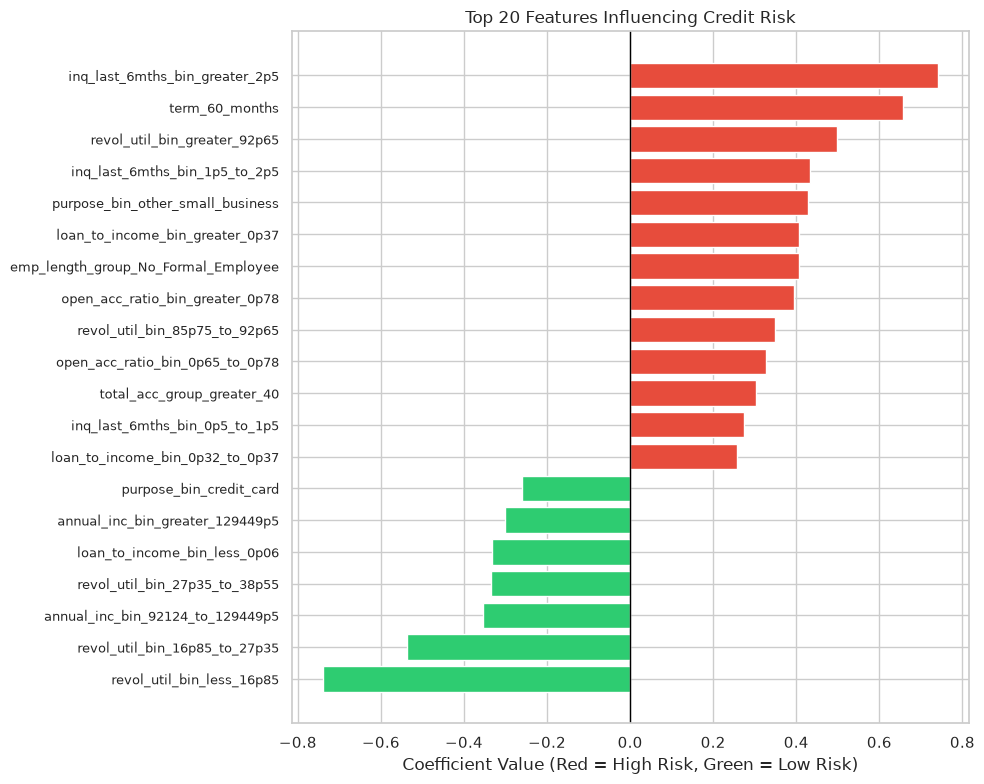

,Characteristics,Coefficient,Point
1,inq_last_6mths_bin_greater_2p5,0.741286,-21
3,term_60_months,0.658004,-19
5,revol_util_bin_greater_92p65,0.497882,-14
6,inq_last_6mths_bin_1p5_to_2p5,0.433408,-13
7,purpose_bin_other_small_business,0.427337,-12
8,loan_to_income_bin_greater_0p37,0.406845,-12
9,emp_length_group_No_Formal_Employee,0.406776,-12
10,open_acc_ratio_bin_greater_0p78,0.393745,-11
12,revol_util_bin_85p75_to_92p65,0.349681,-10
15,open_acc_ratio_bin_0p65_to_0p78,0.327642,-9


In [45]:
def build_comprehensive_scorecard(model, feature_names, target_score=600, target_odds=50, pdo=20):
    """
    Functions for evaluating coefficients and building Credit Scorecards.
    """
    # =======================================================
    # PART 1: SCORECARD PARAMETERS CALCULATION
    # =======================================================
    # Scorecard calibration standard formula:
    factor = pdo / np.log(2)
    offset = target_score - (factor * np.log(target_odds))
    
    intercept = model.intercept_[0]
    coefs = model.coef_[0]
    
    # Since the model predicts BAD (default), a positive probability value indicates high risk.
    # To make a high scorecard score mean "Safe/Good," we assign a negative sign to the coefficient.
    base_score = offset - (intercept * factor)
    
    # =======================================================
    # PART 2: TABLE CREATION AND POINT CALCULATION
    # =======================================================
    # Combine features and coefficients into a DataFrame
    df_scorecard = pd.DataFrame({
        'Characteristics': feature_names,
        'Coefficient': coefs
    })
    
    # Count points and round to integer (banking standard)
    df_scorecard['Point'] = -(df_scorecard['Coefficient'] * factor)
    df_scorecard['Point'] = df_scorecard['Point'].round().astype(int)
    
    # Separate for coefficient analysis
    df_scorecard['Abs_Coefficient'] = df_scorecard['Coefficient'].abs()
    df_scorecard_sorted = df_scorecard.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])
    
    # Prepare the Base Score row to be placed at the top
    base_row = pd.DataFrame({
        'Characteristics': ['Base Score (Intercept)'],
        'Coefficient': [intercept],
        'Point': [round(base_score)]
    })
    
    # Merge into final table
    final_scorecard_table = pd.concat([base_row, df_scorecard_sorted], ignore_index=True)
    
    # =======================================================
    # PART 3: VISUALIZATION & PRINT RESULTS
    # =======================================================
    print(f"=== TOP 5 HIGH RISK INDICATORS (Lower Score) ===")
    top_pos = df_scorecard[df_scorecard['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).head(5)
    print(top_pos[['Characteristics', 'Coefficient', 'Point']].to_string(index=False))
    
    print(f"\n=== TOP 5 LOW RISK INDICATORS (Increasing Score) ===")
    top_neg = df_scorecard[df_scorecard['Coefficient'] < 0].sort_values(by='Coefficient', ascending=True).head(5)
    print(top_neg[['Characteristics', 'Coefficient', 'Point']].to_string(index=False))
    
    # Coefficient Visualization (Using top 20 features to keep the graph from being too crowded)
    top_n_features = df_scorecard.sort_values(by='Abs_Coefficient', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    # Reorder the graph of coefficient values ​​to show the contrast between positive and negative risks.
    top_n_features = top_n_features.sort_values(by='Coefficient', ascending=True) 
    
    colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_n_features['Coefficient']]
    plt.barh(top_n_features['Characteristics'], top_n_features['Coefficient'], color=colors)
    
    plt.xlabel('Coefficient Value (Red = High Risk, Green = Low Risk)')
    plt.title('Top 20 Features Influencing Credit Risk')
    plt.axvline(x=0, color='black', linewidth=1) # Center line boundary 0
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()
    
    return final_scorecard_table

# --- RUN ---
feature_cols = X_train_lr.columns.tolist()
final_scorecard = build_comprehensive_scorecard(
    model=logreg, 
    feature_names=feature_cols, 
    target_score=600, 
    target_odds=50, 
    pdo=20
)

# To view the entire table:
pd.set_option('display.max_rows', None)
final_scorecard.sort_values(by='Coefficient', ascending=False)

In [46]:
from src.helpers import save_best_model

# Save the Best Model to Disk
MODEL_SAVE_PATH = f"./models/LogisticRegression.joblib"
save_best_model(logreg, MODEL_SAVE_PATH)

<br>

---
## **1.7. PCA 2D Visualization** <br>
* Blue = GOOD (0)
* Red  = BAD  (1)

In [47]:
from sklearn.decomposition import PCA

In [48]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

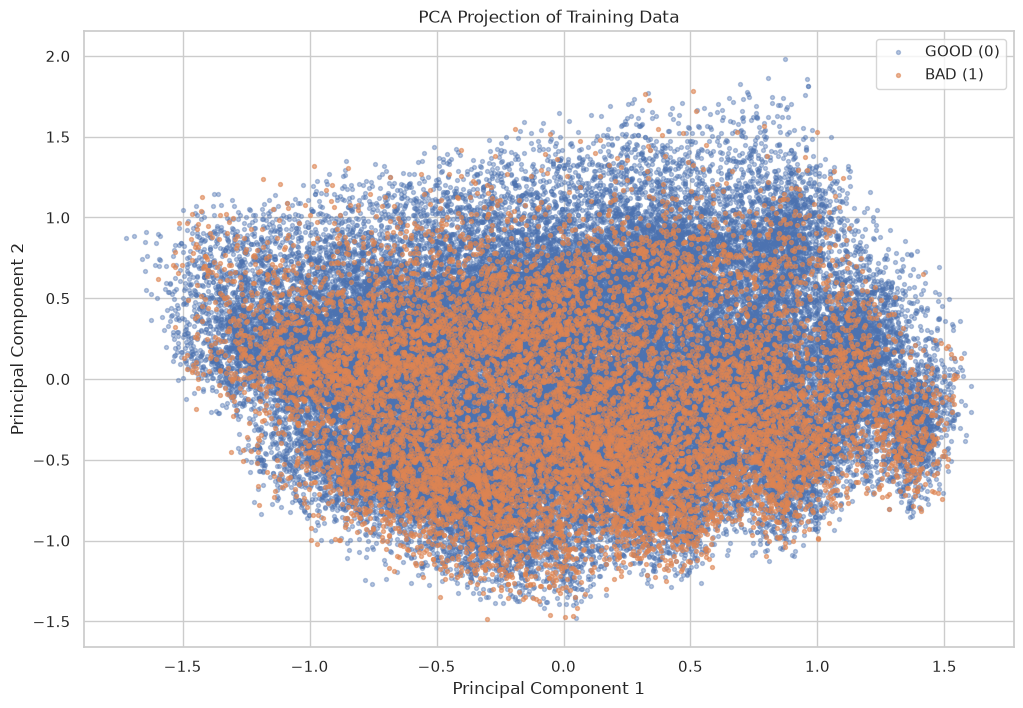

In [49]:
X_pca = pca.fit_transform(
    X_train_lr
)
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'target': y_train.values
})

plt.figure(figsize=(12, 8))

good = plot_df['target'] == 0
bad = plot_df['target'] == 1

plt.scatter(
    plot_df.loc[good, 'PC1'],
    plot_df.loc[good, 'PC2'],
    s=8,
    alpha=0.4,
    label='GOOD (0)',
)

plt.scatter(
    plot_df.loc[bad, 'PC1'],
    plot_df.loc[bad, 'PC2'],
    s=8,
    alpha=0.6,
    label='BAD (1)',
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Training Data')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
from imblearn.over_sampling import BorderlineSMOTE
# Initialize the algorithm
bl_smote = BorderlineSMOTE(
    sampling_strategy=1.0,
    random_state=RANDOM_STATE
)
# Resample train set
X_train_blsmote, y_train_blsmote = bl_smote.fit_resample(
    X_train_lr, y_train
)
print(F"BEFORE BorderlineSMOTE:")
print(y_train.value_counts())

print(F"\nAFTER BorderlineSMOTE:")
print(y_train_blsmote.value_counts())

BEFORE BorderlineSMOTE:
target
0    63862
1    11483
Name: count, dtype: int64

AFTER BorderlineSMOTE:
target
0    63862
1    63862
Name: count, dtype: int64


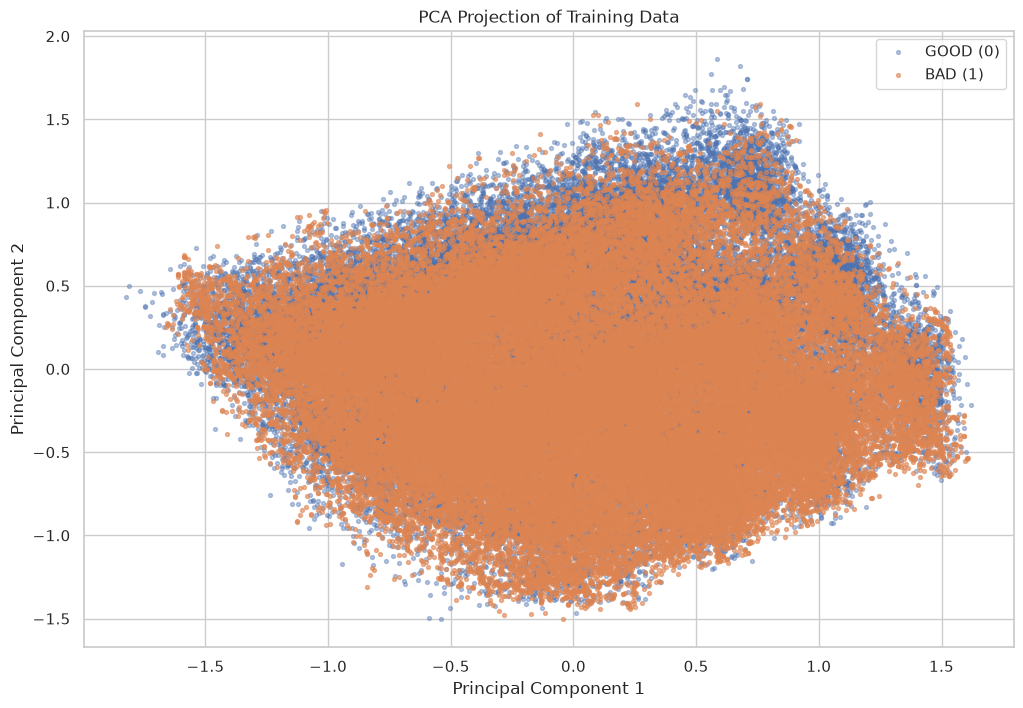

In [51]:
X_pca = pca.fit_transform(
    X_train_blsmote
)
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'target': y_train_blsmote.values
})

plt.figure(figsize=(12, 8))

good = plot_df['target'] == 0
bad = plot_df['target'] == 1

plt.scatter(
    plot_df.loc[good, 'PC1'],
    plot_df.loc[good, 'PC2'],
    s=8,
    alpha=0.4,
    label='GOOD (0)',
)

plt.scatter(
    plot_df.loc[bad, 'PC1'],
    plot_df.loc[bad, 'PC2'],
    s=8,
    alpha=0.6,
    label='BAD (1)',
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Training Data')
plt.legend()
plt.grid(True)
plt.show()

<br>

---
## **1.8. LogReg + BorderlineSMOTE**:

In [52]:
# Refit Logistic Regression
logreg_blsmote = LogisticRegression(
    C=0.38461013019343815,
    class_weight=None,
    l1_ratio=0.4754992118174114,
    max_iter=2000,
    penalty='elasticnet',
    random_state=RANDOM_STATE,
    solver='saga'
)
logreg_blsmote.fit(X_train_blsmote, y_train_blsmote)

LogisticRegression(C=0.38461013019343815, l1_ratio=0.4754992118174114,
                   max_iter=2000, penalty='elasticnet', random_state=42,
                   solver='saga')

<br>

**Evaluate & Predict:**

In [53]:
train_metrics_blsmote, y_pred_train_blsmote, y_proba_train_blsmote = evaluate_model(
    model=logreg_blsmote, 
    X=X_train_lr, y=y_train, 
    model_name='LogReg + BorderlineSMOTE', 
    split_set='Training',
    threshold=optimal_cost_threshold
)

valid_metrics_blsmote, y_pred_valid_blsmote, y_proba_valid_blsmote = evaluate_model(
    model=logreg_blsmote, 
    X=X_valid_lr, y=y_valid, 
    model_name='LogReg + BorderlineSMOTE', 
    split_set='Validation',
    threshold=optimal_cost_threshold
)

test_metrics_blsmote, y_pred_test_blsmote, y_proba_test_blsmote = evaluate_model(
    model=logreg_blsmote, 
    X=X_test_lr, y=y_test, 
    model_name='LogReg + BorderlineSMOTE', 
    split_set='Test',
    threshold=optimal_cost_threshold
)

results = pd.concat([
    train_metrics_blsmote, 
    valid_metrics_blsmote, 
    test_metrics_blsmote
    
], ignore_index=True).set_index(['Model', 'Split'])

results

ROC-AUC    PR-AUC   LogLoss  \
Model                    Split                                      
LogReg + BorderlineSMOTE Training    0.661259  0.253752  0.636465   
                         Validation  0.656989  0.245683  0.644289   
                         Test        0.632959  0.206872  0.668444   

                                     Brier Score      Gini  KS_Statistic  \
Model                    Split                                             
LogReg + BorderlineSMOTE Training       0.222920  0.322518      0.233871   
                         Validation     0.226433  0.313978      0.232482   
                         Test           0.237001  0.265917      0.198154   

                                     Balanced_Accuracy       MCC  \
Model                    Split                                     
LogReg + BorderlineSMOTE Training             0.554499  0.111267   
                         Validation           0.558074  0.117568   
                         Test                 0.536954  0.080462   

                                     Precision_Bad  Recall_Bad    F1_Bad  \
Model                    Split                                             
LogReg + BorderlineSMOTE Training         0.168874    0.947401  0.286652   
                         Validation       0.170027    0.950464  0.288453   
                         Test             0.149465    0.949282  0.258266   

                                     Specificity       NPV       FPR  \
Model                    Split                                         
LogReg + BorderlineSMOTE Training       0.161598  0.944709  0.838402   
                         Validation     0.165683  0.948980  0.834317   
                         Test           0.124625  0.938132  0.875375   

                                          FNR  Predicted_Bad_Rate     TN  \
Model                    Split                                             
LogReg + BorderlineSMOTE Training    0.052599            0.855014  10320   
                         Validation  0.049536            0.852020   1488   
                         Test        0.050718            0.885681   2411   

                                        FP   FN     TP  
Model                    Split                          
LogReg + BorderlineSMOTE Training    53542  604  10879  
                         Validation   7493   80   1535  
                         Test        16935  159   2976

<br>

**Training set comparison**:

In [54]:
results = pd.concat([
    train_metrics, 
    train_metrics_blsmote
    
], ignore_index=True).set_index(['Model', 'Split'])

results

,,ROC-AUC,PR-AUC,LogLoss,Brier Score,Gini,KS_Statistic,Balanced_Accuracy,MCC,Precision_Bad,Recall_Bad,F1_Bad,Specificity,NPV,FPR,FNR,Predicted_Bad_Rate,TN,FP,FN,TP
Model,Split,,,,,,,,,,,,,,,,,,,,
Logistic Regression,Training,0.675443,0.266279,0.401551,0.12250,0.350886,0.253373,0.580730,0.169528,0.306276,0.272403,0.288348,0.889058,0.871722,0.110942,0.727597,0.135550,56777,7085,8355,3128
LogReg + BorderlineSMOTE,Training,0.661259,0.253752,0.636465,0.22292,0.322518,0.233871,0.554499,0.111267,0.168874,0.947401,0.286652,0.161598,0.944709,0.838402,0.052599,0.855014,10320,53542,604,10879


<br>

**Validation set comparison**:

In [55]:
results = pd.concat([
    valid_metrics, 
    valid_metrics_blsmote
    
], ignore_index=True).set_index(['Model', 'Split'])

results

,,ROC-AUC,PR-AUC,LogLoss,Brier Score,Gini,KS_Statistic,Balanced_Accuracy,MCC,Precision_Bad,Recall_Bad,F1_Bad,Specificity,NPV,FPR,FNR,Predicted_Bad_Rate,TN,FP,FN,TP
Model,Split,,,,,,,,,,,,,,,,,,,,
Logistic Regression,Validation,0.671120,0.260084,0.402824,0.122969,0.342239,0.253328,0.583586,0.172506,0.305277,0.282972,0.293702,0.884200,0.872733,0.115800,0.717028,0.14128,7941,1040,1158,457
LogReg + BorderlineSMOTE,Validation,0.656989,0.245683,0.644289,0.226433,0.313978,0.232482,0.558074,0.117568,0.170027,0.950464,0.288453,0.165683,0.948980,0.834317,0.049536,0.85202,1488,7493,80,1535


<br>

**Test set comparison**:

In [56]:
results = pd.concat([
    test_metrics, 
    test_metrics_blsmote
    
], ignore_index=True).set_index(['Model', 'Split'])

results

,,ROC-AUC,PR-AUC,LogLoss,Brier Score,Gini,KS_Statistic,Balanced_Accuracy,MCC,Precision_Bad,Recall_Bad,F1_Bad,Specificity,NPV,FPR,FNR,Predicted_Bad_Rate,TN,FP,FN,TP
Model,Split,,,,,,,,,,,,,,,,,,,,
Logistic Regression,Test,0.644395,0.215537,0.390392,0.117115,0.288791,0.219454,0.563684,0.126978,0.248258,0.250080,0.249166,0.877287,0.878332,0.122713,0.749920,0.140474,16972,2374,2351,784
LogReg + BorderlineSMOTE,Test,0.632959,0.206872,0.668444,0.237001,0.265917,0.198154,0.536954,0.080462,0.149465,0.949282,0.258266,0.124625,0.938132,0.875375,0.050718,0.885681,2411,16935,159,2976
